# 4.3 — Balanced Classification: Extreme-Age-Removed Pipelines

**Why this notebook exists**: Regression-based models in 4.2 achieve only ~5% recall at 80% precision.
They were optimised for MSE loss, never told the no-benefit class matters more.

**This notebook adapts the multi-task approach from notebook 3.6** by training classifiers
**directly on the binary `NO_Benefit` label** (`health_gain < 7`) with class-imbalance correction
on **all four extreme-age-removed datasets**.

## Datasets (all have extreme age removed)

| Dataset | Description |
|---|---|
| `no_extream_age` | Removes Age 1 (40-49) **and** Age 6 (90-120) — primary business ask |
| `removedmissingextreamage` | Removes missing rows + both extreme ages |
| `nohighage` | Removes Age 6 (90-120) only |
| `nolowage` | Removes Age 1 (40-49) only |

## Classifiers (all with imbalance correction)

| Classifier | Imbalance correction |
|---|---|
| RandomForest | `class_weight='balanced'` |
| HistGradientBoosting | `class_weight='balanced'` |
| XGBoost | `scale_pos_weight = neg/pos` |
| LightGBM | `is_unbalance=True` |
| CatBoost | `auto_class_weights='Balanced'` |

## Goal

- **80% Precision** on no-benefit predictions
- **Highest possible Recall** at that precision
- Compare recall improvement vs regression-based baseline (~5%)

> **MCID = 7 pts** (Oxford Knee Score, Beard et al. 2015)  
> **Positive (1) = No benefit** (health gain < 7)  
> **Negative (0) = Benefit** (health gain >= 7)

In [1]:
import subprocess, sys
_packages = ['scikit-learn', 'matplotlib', 'numpy', 'polars', 'pyarrow', 'pandas']
for _p in _packages:
    try: __import__(_p.replace('-','_').split('[')[0])
    except ImportError: subprocess.check_call([sys.executable,'-m','pip','install',_p,'-q'])
print('Core packages OK.')

Core packages OK.


In [2]:
import json, warnings
from pathlib import Path

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.metrics import (
    precision_recall_curve, average_precision_score,
    precision_score, recall_score, fbeta_score, confusion_matrix,
)

# Optional boosting libraries
try:
    from xgboost import XGBClassifier; _HAS_XGB = True
except ImportError:
    _HAS_XGB = False; print('XGBoost not installed (pip install xgboost)')

try:
    from lightgbm import LGBMClassifier; _HAS_LGB = True
except ImportError:
    _HAS_LGB = False; print('LightGBM not installed (pip install lightgbm)')

try:
    from catboost import CatBoostClassifier; _HAS_CAT = True
except ImportError:
    _HAS_CAT = False; print('CatBoost not installed (pip install catboost)')

print('Imports OK.')

Imports OK.


In [3]:
# ── Constants ─────────────────────────────────────────────────────────────────
MCID             = 7.0
TARGET_PRECISION = 0.80
RANDOM_STATE     = 42

# Regression baseline recall from notebook 4.2
REGRESSION_BASELINE_RECALL = 0.058   # best result from 4.2

EXTREME_AGE_SLUGS = [
    'no_extream_age',           # both extremes — primary business ask
    'removedmissingextreamage', # missing + both extremes
    'nohighage',                # high age only
    'nolowage',                 # low age only
]

_PORTAL_BASE  = Path(r'C:\Users\mittall\source\EAISI\NHS\EAISI-NHS\MLPortal\outputs\nhs_knee_replacement')
_DATASETS_DIR = _PORTAL_BASE / 'datasets'
_SESSION_FILE = _PORTAL_BASE / 'session' / 'session_state.json'

assert _SESSION_FILE.exists()
_session  = json.loads(_SESSION_FILE.read_text(encoding='utf-8'))
_TARGET   = _session['upload_cfg']['target_column']
_ds_lookup = {ds['slug']: ds for ds in _session.get('datasets', [])}

print(f'Target: {_TARGET}  |  MCID: {MCID} pts  |  Target precision: {int(TARGET_PRECISION*100)}%')
print(f'Datasets available: {list(_ds_lookup.keys())}')

Target: health_gain  |  MCID: 7.0 pts  |  Target precision: 80%
Datasets available: ['manual_imputation', 'median___mode___flags', 'mice_imputation', 'reduced_features', 'cls_reduced', 'reg_reduced', 'reduced_pipeline_5', 'no_extream_age', 'nohighage', 'nolowage', 'stratifiedmanual', 'removedmissingextreamage', 'removedmissingoldesage', 'removedmissingyoungestage', 'pipeline1']


## 1. Load all extreme-age datasets

In [4]:
datasets = {}   # datasets[slug] = {name, X_train, y_train, X_test, y_test, pos_weight}

for slug in EXTREME_AGE_SLUGS:
    if slug not in _ds_lookup:
        print(f'  [skip] {slug}: not in session_state'); continue

    meta = _ds_lookup[slug]
    train_path = _DATASETS_DIR / meta['train_path']
    test_path  = _DATASETS_DIR / meta['test_path']

    if not train_path.exists() or not test_path.exists():
        print(f'  [skip] {meta["name"]}: parquet file(s) not found'); continue

    train_df = pd.read_parquet(train_path)
    test_df  = pd.read_parquet(test_path)

    # Drop rows where target is NaN
    train_df = train_df.dropna(subset=[_TARGET])
    test_df  = test_df.dropna(subset=[_TARGET])

    # Binary labels: 1 = no benefit
    y_train = (train_df[_TARGET] < MCID).astype(int).values
    y_test  = (test_df[_TARGET]  < MCID).astype(int).values

    # Numeric features only, NaN -> -1
    X_train = train_df.drop(columns=[_TARGET]).select_dtypes(include=[np.number]).fillna(-1)
    X_test  = test_df.drop(columns=[_TARGET]).select_dtypes(include=[np.number]).reindex(
        columns=X_train.columns, fill_value=-1)

    pos = y_train.sum()
    neg = len(y_train) - pos

    datasets[slug] = {
        'name': meta['name'], 'slug': slug,
        'X_train': X_train, 'y_train': y_train,
        'X_test':  X_test,  'y_test':  y_test,
        'pos_weight': neg / pos,
    }
    print(f'  [ok] {meta["name"]:<40}  train={len(y_train):,}  '
          f'no-benefit={pos:,} ({pos/len(y_train):.1%})  imbalance={neg/pos:.1f}x')

print(f'\n{len(datasets)} dataset(s) ready.')

  [ok] No Extream Age                            train=88,373  no-benefit=12,728 (14.4%)  imbalance=5.9x
  [ok] Removed Missing Extreme Age               train=87,482  no-benefit=12,771 (14.6%)  imbalance=5.9x
  [ok] NoHighAge                                 train=88,552  no-benefit=12,804 (14.5%)  imbalance=5.9x
  [ok] NoLowAge                                  train=88,390  no-benefit=12,766 (14.4%)  imbalance=5.9x

4 dataset(s) ready.


## 2. Train balanced classifiers on all datasets

Each (dataset x classifier) combination is trained and evaluated.
The same five classifiers run on every dataset for a fair comparison.

In [5]:
def make_classifiers(pos_weight):
    """Build classifier dict with imbalance correction tuned to dataset's pos_weight."""
    clfs = {
        'RandomForest (balanced)': RandomForestClassifier(
            n_estimators=300, class_weight='balanced', n_jobs=-1, random_state=RANDOM_STATE),
        'HistGBM (balanced)': HistGradientBoostingClassifier(
            class_weight='balanced', random_state=RANDOM_STATE, max_iter=300),
    }
    if _HAS_XGB:
        clfs['XGBoost (balanced)'] = XGBClassifier(
            n_estimators=300, scale_pos_weight=pos_weight, eval_metric='logloss',
            random_state=RANDOM_STATE, verbosity=0)
    if _HAS_LGB:
        clfs['LightGBM (balanced)'] = LGBMClassifier(
            n_estimators=300, is_unbalance=True, random_state=RANDOM_STATE, verbose=-1)
    if _HAS_CAT:
        clfs['CatBoost (balanced)'] = CatBoostClassifier(
            iterations=300, auto_class_weights='Balanced', random_seed=RANDOM_STATE, verbose=0)
    return clfs


def evaluate_pr(y_true, y_proba, threshold=0.5):
    """Return PR metrics dict for a given probability vector."""
    prec_c, rec_c, thr_c = precision_recall_curve(y_true, y_proba)
    ap = float(average_precision_score(y_true, y_proba))
    # operating point at given threshold
    yb = (y_proba >= threshold).astype(int)
    op_prec = float(precision_score(y_true, yb, zero_division=0))
    op_rec  = float(recall_score(y_true, yb, zero_division=0))
    op_f2   = float(fbeta_score(y_true, yb, beta=2, zero_division=0))
    # find threshold achieving TARGET_PRECISION with best recall
    pi, ri = prec_c[:-1], rec_c[:-1]
    valid  = np.where(pi >= TARGET_PRECISION)[0]
    if len(valid) > 0:
        best = valid[np.argmax(ri[valid])]
        tp_thr, tp_prec, tp_rec = float(thr_c[best]), float(pi[best]), float(ri[best])
    else:
        tp_thr = tp_prec = tp_rec = None
    return {
        'ap': ap, 'op_prec': op_prec, 'op_rec': op_rec, 'op_f2': op_f2,
        'tp_thr': tp_thr, 'tp_prec': tp_prec, 'tp_rec': tp_rec,
        'prec_c': prec_c, 'rec_c': rec_c, 'prev': y_true.mean(),
    }


all_cls_results = []   # flat list of result dicts

for slug, ds in datasets.items():
    print(f'\n--- {ds["name"]} ---')
    classifiers = make_classifiers(ds['pos_weight'])
    for clf_name, clf in classifiers.items():
        print(f'  {clf_name}...', end=' ', flush=True)
        with warnings.catch_warnings():
            warnings.simplefilter('ignore')
            clf.fit(ds['X_train'], ds['y_train'])
        y_proba = clf.predict_proba(ds['X_test'])[:, 1]
        m = evaluate_pr(ds['y_test'], y_proba)
        status = f'AP={m["ap"]:.3f}  Recall@P80={m["tp_rec"]:.3f}' if m['tp_rec'] else \
                 f'AP={m["ap"]:.3f}  cannot reach {int(TARGET_PRECISION*100)}% prec'
        print(status)
        all_cls_results.append({
            'Dataset':        ds['name'],
            'Model':          clf_name,
            'AP':             round(m['ap'],      4),
            'Precision@0.5':  round(m['op_prec'], 4),
            'Recall@0.5':     round(m['op_rec'],  4),
            'F2@0.5':         round(m['op_f2'],   4),
            'Prevalence (%)': round(m['prev']*100, 1),
            f'Thr@P{int(TARGET_PRECISION*100)}':    round(m['tp_thr'],  4) if m['tp_thr']  else None,
            f'Prec@P{int(TARGET_PRECISION*100)}':   round(m['tp_prec'], 4) if m['tp_prec'] else None,
            f'Recall@P{int(TARGET_PRECISION*100)}': round(m['tp_rec'],  4) if m['tp_rec']  else None,
            # private
            '_prec_c': m['prec_c'], '_rec_c': m['rec_c'],
            '_op_prec': m['op_prec'], '_op_rec': m['op_rec'],
            '_tp_thr': m['tp_thr'], '_tp_prec': m['tp_prec'], '_tp_rec': m['tp_rec'],
            '_prev': m['prev'],
        })

print(f'\n{len(all_cls_results)} (dataset x classifier) combinations evaluated.')


--- No Extream Age ---
  RandomForest (balanced)... AP=0.332  Recall@P80=0.035
  HistGBM (balanced)... AP=0.353  Recall@P80=0.041
  XGBoost (balanced)... AP=0.307  Recall@P80=0.035
  LightGBM (balanced)... AP=0.344  Recall@P80=0.043
  CatBoost (balanced)... AP=0.339  Recall@P80=0.038

--- Removed Missing Extreme Age ---
  RandomForest (balanced)... AP=0.324  Recall@P80=0.038
  HistGBM (balanced)... AP=0.348  Recall@P80=0.045
  XGBoost (balanced)... AP=0.301  Recall@P80=0.029
  LightGBM (balanced)... AP=0.342  Recall@P80=0.047
  CatBoost (balanced)... AP=0.340  Recall@P80=0.049

--- NoHighAge ---
  RandomForest (balanced)... AP=0.334  Recall@P80=0.036
  HistGBM (balanced)... AP=0.352  Recall@P80=0.043
  XGBoost (balanced)... AP=0.303  Recall@P80=0.030
  LightGBM (balanced)... AP=0.347  Recall@P80=0.041
  CatBoost (balanced)... AP=0.342  Recall@P80=0.045

--- NoLowAge ---
  RandomForest (balanced)... AP=0.327  Recall@P80=0.028
  HistGBM (balanced)... AP=0.347  Recall@P80=0.042
  XGBoost

## 3. Results Table — All Combinations

In [6]:
thr_col = f'Thr@P{int(TARGET_PRECISION*100)}'
rec_col = f'Recall@P{int(TARGET_PRECISION*100)}'

results_df = (
    pl.DataFrame([{k: v for k, v in r.items() if not k.startswith('_')} for r in all_cls_results])
    .sort(rec_col, descending=True, nulls_last=True)
)

print(f'=== All (Dataset x Classifier) combinations — ranked by Recall@P{int(TARGET_PRECISION*100)} ===')
print(f'Positive (1) = No benefit (gain < {MCID} pts)  |  Regression baseline recall = {REGRESSION_BASELINE_RECALL:.1%}\n')
print(results_df)

=== All (Dataset x Classifier) combinations — ranked by Recall@P80 ===
Positive (1) = No benefit (gain < 7.0 pts)  |  Regression baseline recall = 5.8%

shape: (20, 10)
┌────────────┬────────────┬────────┬────────────┬───┬────────────┬─────────┬──────────┬────────────┐
│ Dataset    ┆ Model      ┆ AP     ┆ Precision@ ┆ … ┆ Prevalence ┆ Thr@P80 ┆ Prec@P80 ┆ Recall@P80 │
│ ---        ┆ ---        ┆ ---    ┆ 0.5        ┆   ┆ (%)        ┆ ---     ┆ ---      ┆ ---        │
│ str        ┆ str        ┆ f64    ┆ ---        ┆   ┆ ---        ┆ f64     ┆ f64      ┆ f64        │
│            ┆            ┆        ┆ f64        ┆   ┆ f64        ┆         ┆          ┆            │
╞════════════╪════════════╪════════╪════════════╪═══╪════════════╪═════════╪══════════╪════════════╡
│ Removed    ┆ CatBoost   ┆ 0.3395 ┆ 0.2663     ┆ … ┆ 14.5       ┆ 0.9116  ┆ 0.8021   ┆ 0.0486     │
│ Missing    ┆ (balanced) ┆        ┆            ┆   ┆            ┆         ┆          ┆            │
│ Extreme    ┆         

In [7]:
# ── Top candidates that achieved 80% precision ────────────────────────────────
candidates = sorted([r for r in all_cls_results if r['_tp_rec'] is not None],
                    key=lambda r: r['_tp_rec'], reverse=True)

print(f'=== Models achieving {int(TARGET_PRECISION*100)}% Precision ===')
print(f'Regression baseline recall: {REGRESSION_BASELINE_RECALL:.1%}\n')
print(f'{"#":<3} {"Dataset":<35} {"Model":<32} {"Thr":<8} {"Precision":<12} {"Recall":<10} {"AP"}')
print('-' * 105)
for i, r in enumerate(candidates):
    thr_s  = f'{r["_tp_thr"]:.4f}'
    marker = ' <- BEST' if i == 0 else ''
    print(f'{i+1:<3} {r["Dataset"]:<35} {r["Model"]:<32} {thr_s:<8} '
          f'{r["_tp_prec"]:<12.3f} {r["_tp_rec"]:<10.3f} {r["AP"]:.4f}{marker}')

if not candidates:
    print('No combination reached 80% precision.')
    print('Consider: lower target precision or add more discriminative features.')
else:
    best = candidates[0]
    gain = best['_tp_rec'] - REGRESSION_BASELINE_RECALL
    pct  = gain / max(REGRESSION_BASELINE_RECALL, 1e-9) * 100
    print(f'\nBest recall improvement over regression baseline: +{gain:.3f} ({pct:+.0f}%)')

=== Models achieving 80% Precision ===
Regression baseline recall: 5.8%

#   Dataset                             Model                            Thr      Precision    Recall     AP
---------------------------------------------------------------------------------------------------------
1   Removed Missing Extreme Age         CatBoost (balanced)              0.9116   0.802        0.049      0.3395 <- BEST
2   Removed Missing Extreme Age         LightGBM (balanced)              0.8997   0.801        0.047      0.3420
3   Removed Missing Extreme Age         HistGBM (balanced)               0.8892   0.800        0.045      0.3479
4   NoHighAge                           CatBoost (balanced)              0.9220   0.802        0.045      0.3424
5   No Extream Age                      LightGBM (balanced)              0.9014   0.800        0.043      0.3437
6   NoHighAge                           HistGBM (balanced)               0.8894   0.802        0.043      0.3522
7   NoLowAge              

## 4. Precision-Recall Curves — Best Model per Dataset

Shows the top-performing classifier for each extreme-age dataset.

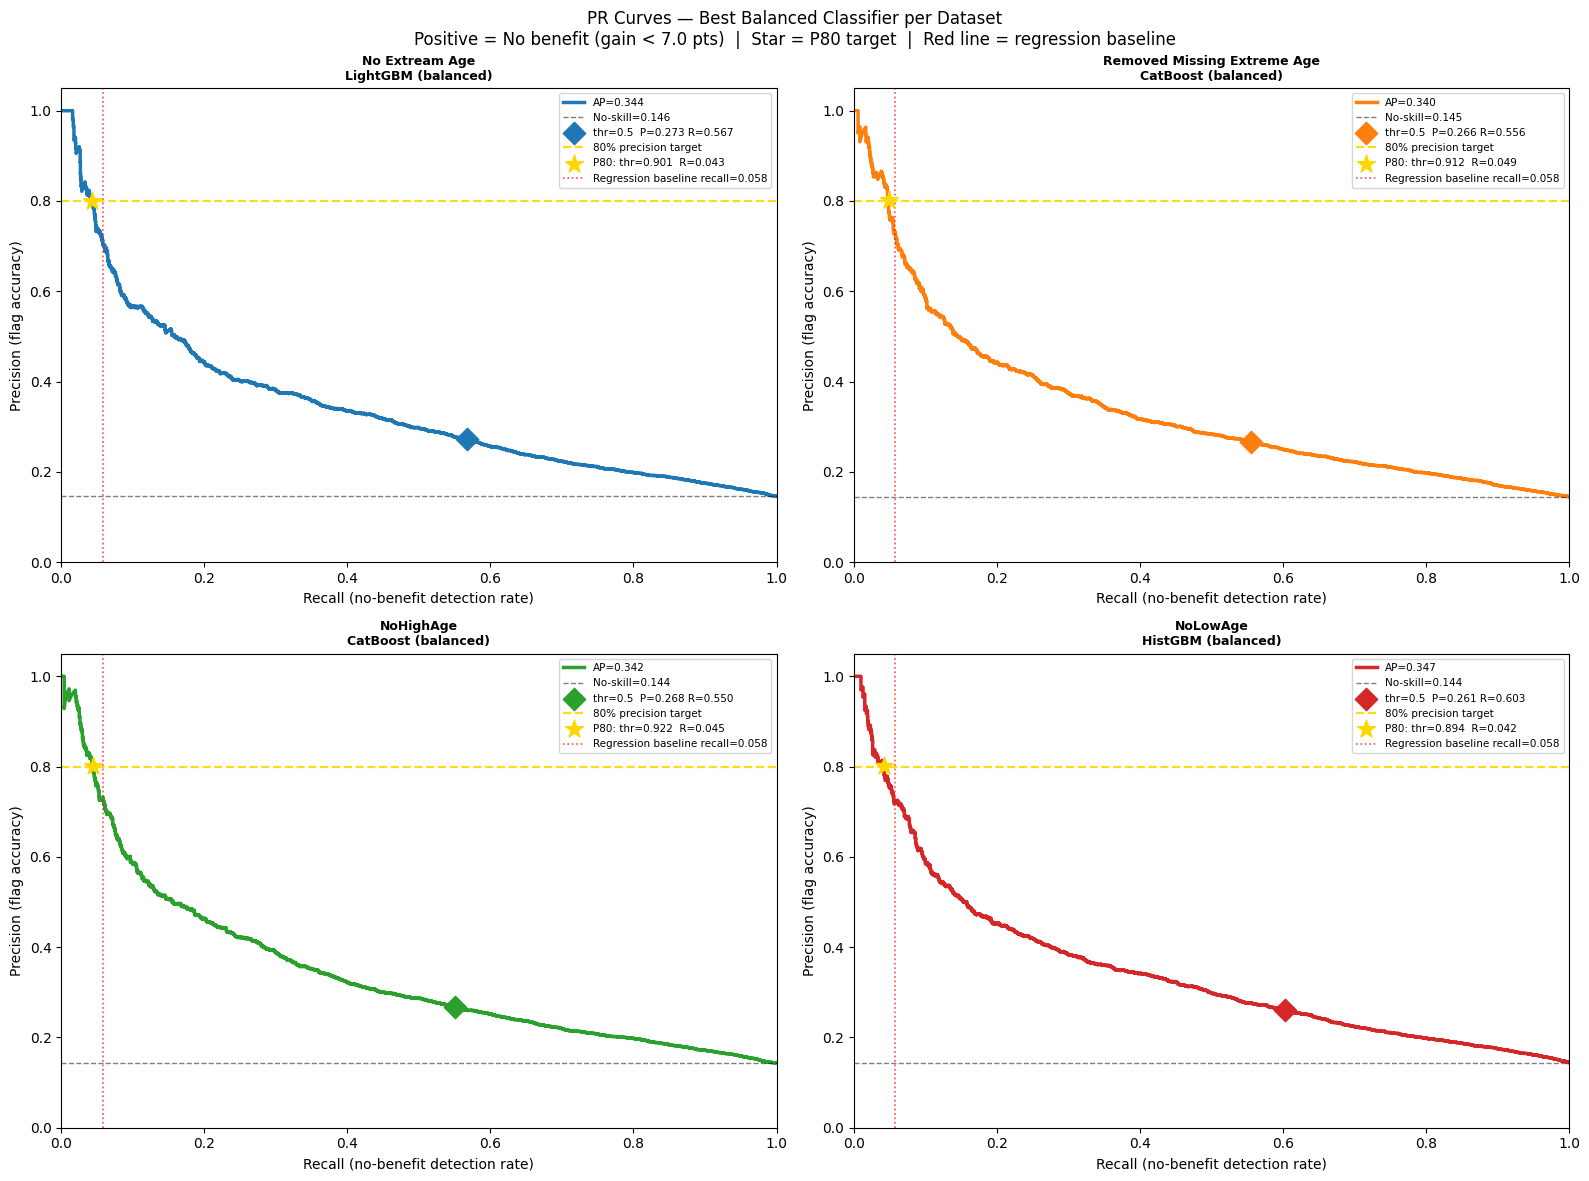

In [8]:
# Select best model per dataset (highest recall at P80, fallback to highest AP)
best_per_ds = {}
for r in all_cls_results:
    ds = r['Dataset']
    prev = best_per_ds.get(ds)
    if prev is None:
        best_per_ds[ds] = r
    else:
        curr_rec = r['_tp_rec'] or -1
        prev_rec = prev['_tp_rec'] or -1
        if curr_rec > prev_rec or (curr_rec == prev_rec and r['AP'] > prev['AP']):
            best_per_ds[ds] = r

plot_rows = list(best_per_ds.values())
n = len(plot_rows)
ncols = min(n, 2); nrows = (n + ncols - 1) // ncols
fig, axes = plt.subplots(nrows, ncols, figsize=(8*ncols, 6*nrows), squeeze=False)
axes_flat = axes.flatten()
cmap = plt.get_cmap('tab10')

for i, row in enumerate(plot_rows):
    ax = axes_flat[i]
    ax.plot(row['_rec_c'], row['_prec_c'], color=cmap(i), linewidth=2.5, label=f'AP={row["AP"]:.3f}')
    ax.axhline(row['_prev'], color='k', linestyle='--', linewidth=1, alpha=0.5,
               label=f'No-skill={row["_prev"]:.3f}')
    # Default operating point (0.5 threshold)
    ax.scatter([row['_op_rec']], [row['_op_prec']], s=130, color=cmap(i), marker='D', zorder=6,
               label=f'thr=0.5  P={row["_op_prec"]:.3f} R={row["_op_rec"]:.3f}')
    # 80% precision target line
    ax.axhline(TARGET_PRECISION, color='gold', linestyle='--', linewidth=1.6, alpha=0.9,
               label=f'{int(TARGET_PRECISION*100)}% precision target')
    # P80 operating point
    if row['_tp_thr'] is not None:
        ax.scatter([row['_tp_rec']], [row['_tp_prec']], s=180, color='gold', marker='*', zorder=7,
                   label=f'P80: thr={row["_tp_thr"]:.3f}  R={row["_tp_rec"]:.3f}')
        # show regression baseline for comparison
        ax.axvline(REGRESSION_BASELINE_RECALL, color='red', linestyle=':', linewidth=1.2, alpha=0.7,
                   label=f'Regression baseline recall={REGRESSION_BASELINE_RECALL:.3f}')
    else:
        ax.text(0.5, TARGET_PRECISION+0.02, 'Cannot reach target', ha='center', fontsize=8, color='grey')
    ax.set_xlabel('Recall (no-benefit detection rate)', fontsize=10)
    ax.set_ylabel('Precision (flag accuracy)', fontsize=10)
    ax.set_title(f'{row["Dataset"]}\n{row["Model"]}', fontsize=9, fontweight='bold')
    ax.legend(fontsize=7.5); ax.set_xlim(0,1); ax.set_ylim(0,1.05)

for j in range(n, len(axes_flat)): axes_flat[j].set_visible(False)
fig.suptitle(
    f'PR Curves — Best Balanced Classifier per Dataset\n'
    f'Positive = No benefit (gain < {MCID} pts)  |  Star = P80 target  |  Red line = regression baseline',
    fontsize=12
)
plt.tight_layout(); plt.show()

## 5. Confusion Matrix — Best Overall Model

Shows how many unnecessary surgeries are caught vs missed at:
- Default threshold (0.5 probability)
- Tuned P80 threshold

Re-training best model: CatBoost (balanced) on Removed Missing Extreme Age...


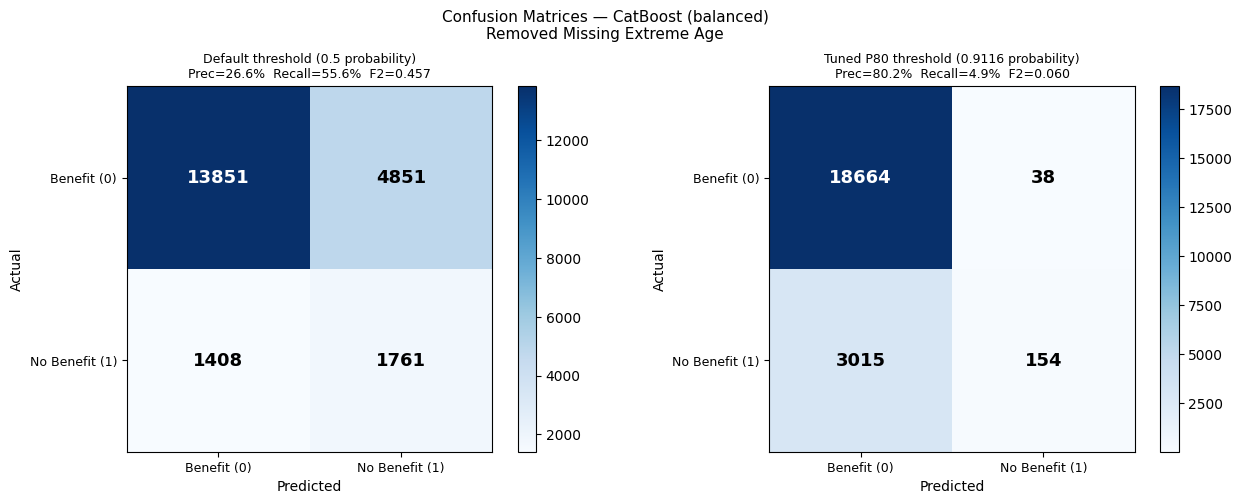


Total patients in test set : 21,871
True no-benefit patients   : 3,169  (14.5%)

At P80 threshold (0.9116):
  Unnecessary surgeries caught (TP) : 154  (4.9% of all no-benefit)
  Unnecessary surgeries missed (FN) : 3,015  (95.1% of all no-benefit)
  False alarms (FP)                 : 38  (patients wrongly denied surgery)


In [9]:
if not candidates:
    print('No model reached 80% precision.')
else:
    best = candidates[0]
    slug = next(s for s, d in datasets.items() if d['name'] == best['Dataset'])
    ds   = datasets[slug]

    # Re-train best classifier to get probabilities
    print(f'Re-training best model: {best["Model"]} on {best["Dataset"]}...')
    clfs = make_classifiers(ds['pos_weight'])
    clf  = clfs[best['Model']]
    with warnings.catch_warnings():
        warnings.simplefilter('ignore')
        clf.fit(ds['X_train'], ds['y_train'])
    y_proba  = clf.predict_proba(ds['X_test'])[:, 1]
    y_true   = ds['y_test']

    fig, axes = plt.subplots(1, 2, figsize=(13, 5))
    for ax, (label, thr) in zip(axes, [
        (f'Default threshold (0.5 probability)', 0.5),
        (f'Tuned P80 threshold ({best["_tp_thr"]:.4f} probability)', best['_tp_thr']),
    ]):
        yb = (y_proba >= thr).astype(int)
        cm = confusion_matrix(y_true, yb)
        p  = precision_score(y_true, yb, zero_division=0)
        r  = recall_score(y_true, yb, zero_division=0)
        f2 = fbeta_score(y_true, yb, beta=2, zero_division=0)
        im = ax.imshow(cm, cmap=plt.cm.Blues)
        ax.set_title(f'{label}\nPrec={p:.1%}  Recall={r:.1%}  F2={f2:.3f}', fontsize=9)
        for row_i in range(2):
            for col_i in range(2):
                ax.text(col_i, row_i, format(cm[row_i,col_i],'d'), ha='center', va='center',
                        fontsize=13, fontweight='bold',
                        color='white' if cm[row_i,col_i]>cm.max()/2 else 'black')
        ax.set_xticks([0,1]); ax.set_xticklabels(['Benefit (0)','No Benefit (1)'], fontsize=9)
        ax.set_yticks([0,1]); ax.set_yticklabels(['Benefit (0)','No Benefit (1)'], fontsize=9)
        ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
        plt.colorbar(im, ax=ax)

    fig.suptitle(f'Confusion Matrices — {best["Model"]}\n{best["Dataset"]}', fontsize=11)
    plt.tight_layout(); plt.show()

    # Clinical interpretation
    p80_yb = (y_proba >= best['_tp_thr']).astype(int)
    cm80   = confusion_matrix(y_true, p80_yb)
    n_no_benefit = y_true.sum()
    print(f'\nTotal patients in test set : {len(y_true):,}')
    print(f'True no-benefit patients   : {n_no_benefit:,}  ({n_no_benefit/len(y_true):.1%})')
    print(f'\nAt P80 threshold ({best["_tp_thr"]:.4f}):')
    print(f'  Unnecessary surgeries caught (TP) : {cm80[1,1]:,}  ({cm80[1,1]/n_no_benefit:.1%} of all no-benefit)')
    print(f'  Unnecessary surgeries missed (FN) : {cm80[1,0]:,}  ({cm80[1,0]/n_no_benefit:.1%} of all no-benefit)')
    print(f'  False alarms (FP)                 : {cm80[0,1]:,}  (patients wrongly denied surgery)')

## 6. Recall Improvement vs Regression Baseline

In [10]:
print('=== Recall@P80 Comparison: Balanced Classifiers vs Regression Baseline (4.2) ===')
print(f'Regression baseline (best from 4.2): {REGRESSION_BASELINE_RECALL:.1%}\n')

# Group by classifier type to show which model type consistently wins
by_model = {}
for r in all_cls_results:
    m = r['Model']
    if m not in by_model or (r['_tp_rec'] or 0) > (by_model[m]['_tp_rec'] or 0):
        by_model[m] = r

print(f'Best result per classifier type across all extreme-age datasets:')
print(f'{"Model":<35} {"Best Dataset":<35} {"Recall@P80":<12} {"vs baseline"}')
print('-' * 90)
for mdl, r in sorted(by_model.items(), key=lambda x: x[1]['_tp_rec'] or 0, reverse=True):
    rec_s = f'{r["_tp_rec"]:.3f}' if r['_tp_rec'] else 'N/A'
    diff  = f'+{r["_tp_rec"]-REGRESSION_BASELINE_RECALL:+.3f}' if r['_tp_rec'] else '-'
    print(f'{mdl:<35} {r["Dataset"]:<35} {rec_s:<12} {diff}')

=== Recall@P80 Comparison: Balanced Classifiers vs Regression Baseline (4.2) ===
Regression baseline (best from 4.2): 5.8%

Best result per classifier type across all extreme-age datasets:
Model                               Best Dataset                        Recall@P80   vs baseline
------------------------------------------------------------------------------------------
CatBoost (balanced)                 Removed Missing Extreme Age         0.049        +-0.009
LightGBM (balanced)                 Removed Missing Extreme Age         0.047        +-0.011
HistGBM (balanced)                  Removed Missing Extreme Age         0.045        +-0.013
RandomForest (balanced)             Removed Missing Extreme Age         0.038        +-0.020
XGBoost (balanced)                  No Extream Age                      0.035        +-0.023


## 7. Final Recommendation

In [11]:
print('=' * 72)
print('FINAL RECOMMENDATION — Balanced Classification')
print('=' * 72)
print(f'Business ask  : Remove extreme age (40-49, 90-120) | {int(TARGET_PRECISION*100)}% Precision')
print(f'Regression baseline recall (notebook 4.2): {REGRESSION_BASELINE_RECALL:.1%}')
print()

if not candidates:
    print('No combination reached 80% precision.')
    print('Suggestions:')
    print('  1. Lower TARGET_PRECISION to 0.70 and re-run')
    print('  2. Add engineered features (notebook 2.4)')
    print('  3. Try a two-stage model: recall-optimised stage 1 → precision stage 2')
else:
    best = candidates[0]
    gain = best['_tp_rec'] - REGRESSION_BASELINE_RECALL
    pct  = gain / max(REGRESSION_BASELINE_RECALL, 1e-9) * 100

    print(f'Best model    : {best["Model"]}')
    print(f'Dataset       : {best["Dataset"]}')
    print(f'Precision@P80 : {best["_tp_prec"]:.1%}')
    print(f'Recall@P80    : {best["_tp_rec"]:.1%}  (regression baseline: {REGRESSION_BASELINE_RECALL:.1%}  gain: +{gain:.1%}  / {pct:+.0f}%)')
    print(f'P80 threshold : {best["_tp_thr"]:.4f} (probability score, not OKS pts)')
    print(f'AP            : {best["AP"]}')
    print()
    print('Deployment code:')
    print(f'  DECISION_THR = {best["_tp_thr"]:.4f}')
    print(f'  y_pred_bin   = (clf.predict_proba(X_test)[:,1] >= DECISION_THR).astype(int)')
    print(f'  # 1 = no benefit (flag for review)')
    print()
    print('Full leaderboard:')
    print(f'{"#":<3} {"Dataset":<35} {"Model":<32} {"Thr":<8} {"Recall":<10} {"AP"}')
    print('-' * 95)
    for i, r in enumerate(candidates):
        marker = ' <- BEST' if i == 0 else ''
        print(f'{i+1:<3} {r["Dataset"]:<35} {r["Model"]:<32} {r["_tp_thr"]:<8.4f} {r["_tp_rec"]:<10.3f} {r["AP"]:.4f}{marker}')

FINAL RECOMMENDATION — Balanced Classification
Business ask  : Remove extreme age (40-49, 90-120) | 80% Precision
Regression baseline recall (notebook 4.2): 5.8%

Best model    : CatBoost (balanced)
Dataset       : Removed Missing Extreme Age
Precision@P80 : 80.2%
Recall@P80    : 4.9%  (regression baseline: 5.8%  gain: +-0.9%  / -16%)
P80 threshold : 0.9116 (probability score, not OKS pts)
AP            : 0.3395

Deployment code:
  DECISION_THR = 0.9116
  y_pred_bin   = (clf.predict_proba(X_test)[:,1] >= DECISION_THR).astype(int)
  # 1 = no benefit (flag for review)

Full leaderboard:
#   Dataset                             Model                            Thr      Recall     AP
-----------------------------------------------------------------------------------------------
1   Removed Missing Extreme Age         CatBoost (balanced)              0.9116   0.049      0.3395 <- BEST
2   Removed Missing Extreme Age         LightGBM (balanced)              0.8997   0.047      0.3420
3   Remo